Loading data and Block C model objects...
  Data loaded.

Re-computing all metrics...

All metrics computed.

STUDENT PERFORMANCE & DROPOUT EARLY WARNING SYSTEM
Phase 3: Statistical Analysis — Findings Report
Dataset : Open University Learning Analytics (OULAD)
Date    : June 01, 2026

1. ANALYSIS CONTEXT
─────────────────────────────────────────────────────────────────
  Phase 3 formally tests the patterns observed in Phase 2 EDA.
  Tests performed:
    Block A — Chi-square tests   : categorical features vs dropout
    Block B — Welch's t-tests    : numeric features vs dropout
    Block C — Logistic regression: multivariate dropout model
    Block D — Odds ratios        : effect size interpretation
  Significance threshold: p < 0.05 throughout
  Total student-course rows: 32,593
  Overall dropout rate     : 31.2%

2. CHI-SQUARE TEST RESULTS (Block A)
─────────────────────────────────────────────────────────────────
  H0: Feature is independent of dropout

  Feature                    

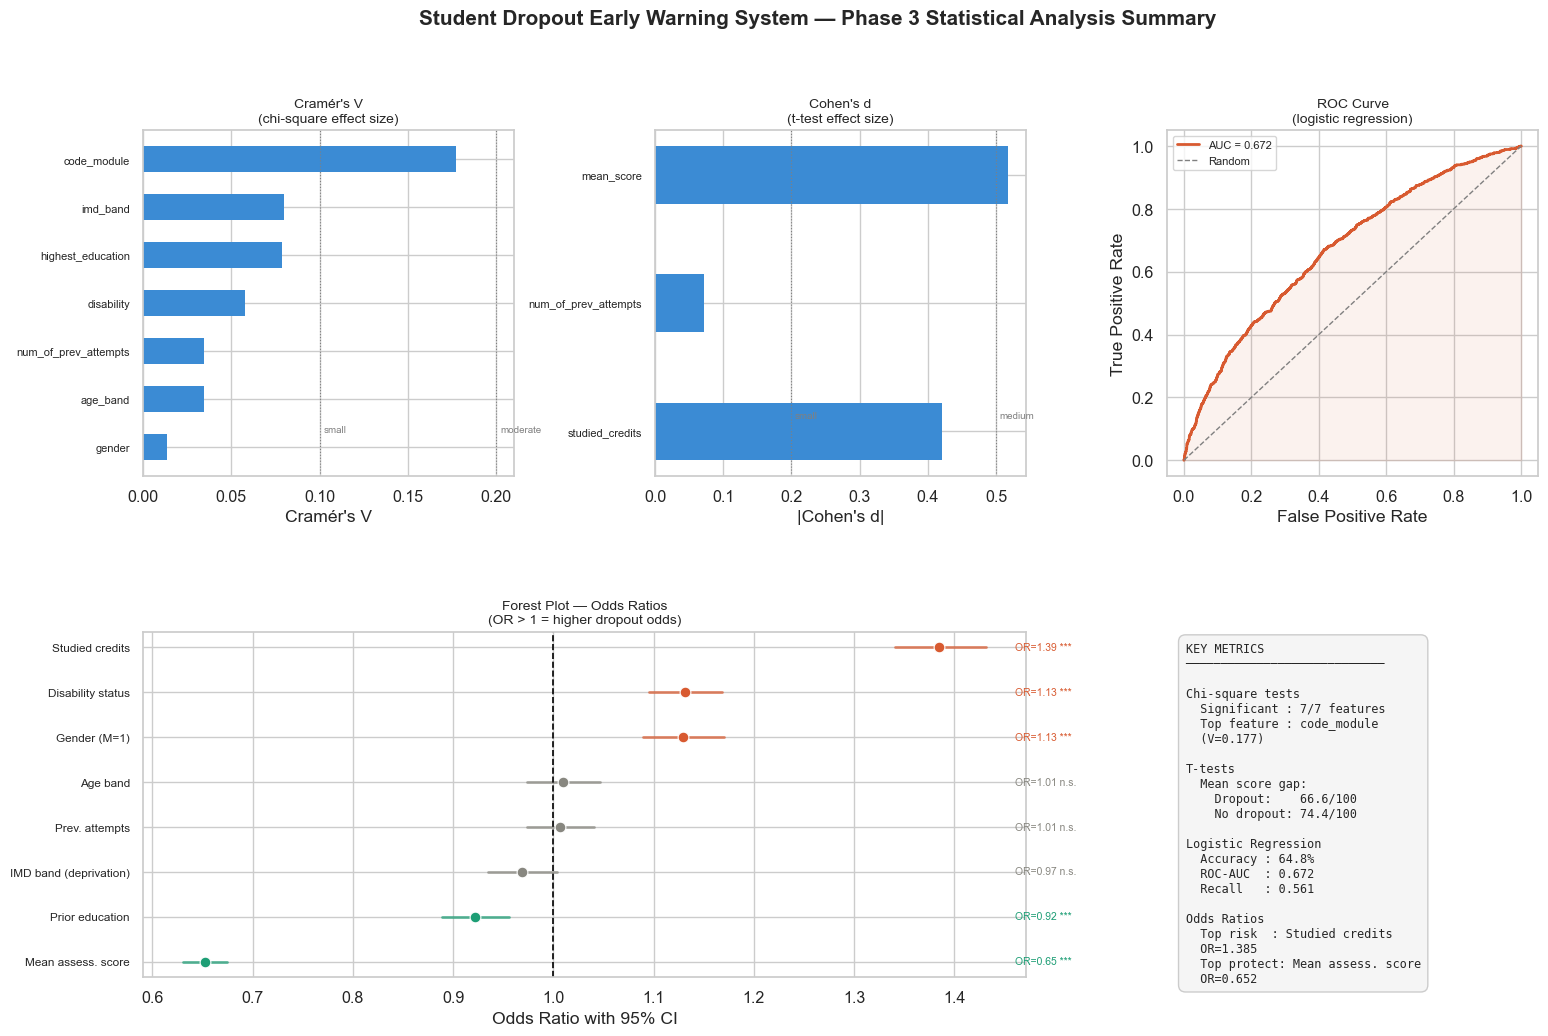

  ✅ Dashboard saved → ./outputs/phase3/block_e/phase3_summary_dashboard.png

BLOCK E COMPLETE — Phase 3 is DONE

  Files saved to: ./outputs/phase3/block_e/
    ✅ phase3_findings_report.txt    ← copy into your portfolio
    ✅ phase3_summary_dashboard.png  ← use in README / slides

  Phase 3 Statistical Analysis — all blocks complete:
    Block A — Chi-square tests       ✅
    Block B — T-tests and ANOVA      ✅
    Block C — Logistic regression    ✅
    Block D — Odds ratios            ✅
    Block E — Summary report         ✅

───────────────────────────────────────────────────────
Next → Phase 4: Machine Learning Model
  Random Forest, XGBoost, SMOTE, SHAP values,
  cross-validated AUC, dropout risk scoring
───────────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 3 — Block E: Summary and Portfolio Findings Report
=============================================================
Goal: Re-run all key calculations from Blocks A–D and compile
      them into a structured, portfolio-ready findings report.

Outputs:
  1. Structured findings printed to console
  2. phase3_findings_report.txt  ← paste into your portfolio
  3. phase3_summary_dashboard.png ← use in README/presentation

Run this AFTER Blocks A, B, C, and D are complete.
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from datetime import date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score
import statsmodels.api as sm

# ── Config ────────────────────────────────────────────────────
DATA_PATH    = './data/'
BLOCK_C_PATH = './outputs/phase3/block_c/'
OUTPUT_PATH  = './outputs/phase3/block_e/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
RANDOM_STATE = 42

# ── Load data ─────────────────────────────────────────────────
print("Loading data and Block C model objects...")

si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
sa = pd.read_csv(DATA_PATH + 'studentAssessment.csv')
si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

mean_scores = (
    sa.groupby('id_student')['score']
      .mean()
      .reset_index()
      .rename(columns={'score': 'mean_score'})
)
si = si.merge(mean_scores, on='id_student', how='left')

with open(os.path.join(BLOCK_C_PATH, 'block_c_objects.pkl'), 'rb') as f:
    c_objects = pickle.load(f)

result         = c_objects['result']
coef_df        = c_objects['coef_df']
FEATURES       = c_objects['FEATURES']
FEATURE_LABELS = c_objects['FEATURE_LABELS']
roc_auc        = c_objects['roc_auc']
accuracy       = c_objects['accuracy']

print("  Data loaded.\n")


# =============================================================
# STEP 1: Re-compute all key metrics
# =============================================================
print("Re-computing all metrics...\n")

overall_rate = si['dropout'].mean() * 100
n_dropout    = si['dropout'].sum()
n_total      = len(si)

# ── Block A: chi-square for all categorical features ──────────
cat_features = [
    'gender', 'age_band', 'highest_education',
    'imd_band', 'disability', 'num_of_prev_attempts', 'code_module'
]
chi2_results = {}
for feat in cat_features:
    clean = si[[feat, 'dropout']].dropna()
    ct    = pd.crosstab(clean[feat], clean['dropout'])
    chi2_val, p_val, dof, expected = chi2_contingency(ct)
    n, k  = len(clean), min(ct.shape) - 1
    v     = np.sqrt(chi2_val / (n * k)) if k > 0 else 0.0
    chi2_results[feat] = {'chi2': chi2_val, 'p': p_val, 'v': v,
                          'sig': p_val < 0.05}

sig_chi2     = [f for f, r in chi2_results.items() if r['sig']]
nonsig_chi2  = [f for f, r in chi2_results.items() if not r['sig']]
top_chi2_feat = max(chi2_results, key=lambda f: chi2_results[f]['v'])
top_chi2_v    = chi2_results[top_chi2_feat]['v']

# ── Block B: t-tests ──────────────────────────────────────────
ttest_results = {}
for col in ['studied_credits', 'num_of_prev_attempts', 'mean_score']:
    clean = si[[col, 'dropout']].dropna()
    g1    = clean[clean['dropout'] == 1][col]
    g0    = clean[clean['dropout'] == 0][col]
    t, p  = stats.ttest_ind(g1, g0, equal_var=False)
    n1, n0 = len(g1), len(g0)
    var1, var0 = g1.var(ddof=1), g0.var(ddof=1)
    pooled = np.sqrt(((n1-1)*var1 + (n0-1)*var0) / (n1+n0-2))
    d = (g1.mean() - g0.mean()) / pooled if pooled > 0 else 0
    ttest_results[col] = {
        't': t, 'p': p, 'd': d,
        'mean_drop': g1.mean(), 'mean_nodrop': g0.mean(),
        'sig': p < 0.05
    }

# ── Block C: logistic regression ─────────────────────────────
# Rebuild model to get fresh predictions
df_enc = si.copy()
df_enc['edu_enc']    = df_enc['highest_education'].map({
    'No Formal quals': 0, 'Lower Than A Level': 1,
    'A Level or Equivalent': 2, 'HE Qualification': 3,
    'Post Graduate Qualification': 4})
df_enc['imd_enc']    = df_enc['imd_band'].map({
    '0-10%': 0, '10-20': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9})
df_enc['age_enc']    = df_enc['age_band'].map({'0-35': 0, '35-55': 1, '55<=': 2})
df_enc['gender_enc'] = (df_enc['gender'] == 'M').astype(int)
df_enc['disab_enc']  = (df_enc['disability'] == 'Y').astype(int)

df_model  = df_enc[FEATURES + ['dropout']].dropna()
X = df_model[FEATURES]
y = df_model['dropout']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                        class_weight='balanced')
lr.fit(X_tr_sc, y_train)
y_pred       = lr.predict(X_te_sc)
y_proba      = lr.predict_proba(X_te_sc)[:, 1]
roc_auc_val  = roc_auc_score(y_test, y_proba)
accuracy_val = accuracy_score(y_test, y_pred)
cm           = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# ── Block D: odds ratios ───────────────────────────────────────
feat_rows = coef_df[coef_df['Feature'] != 'Intercept'].copy()
feat_rows['OR']       = np.exp(feat_rows['Coef (β)'])
feat_rows['OR_lower'] = np.exp(feat_rows['CI lower'])
feat_rows['OR_upper'] = np.exp(feat_rows['CI upper'])
feat_rows['Sig']      = feat_rows['p-value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.')

sig_increase = feat_rows[(feat_rows['OR'] > 1) & (feat_rows['Sig'] != 'n.s.')]['Feature'].tolist()
sig_decrease = feat_rows[(feat_rows['OR'] < 1) & (feat_rows['Sig'] != 'n.s.')]['Feature'].tolist()
not_sig_or   = feat_rows[feat_rows['Sig'] == 'n.s.']['Feature'].tolist()

top_risk        = feat_rows[feat_rows['OR'] > 1].nlargest(1, 'OR').iloc[0]
top_protective  = feat_rows[feat_rows['OR'] < 1].nsmallest(1, 'OR').iloc[0]

print("All metrics computed.\n")


# =============================================================
# STEP 2: Print structured findings report
# =============================================================
DIVIDER = "=" * 65
SUBDIV  = "─" * 65
TODAY   = date.today().strftime("%B %d, %Y")

report_lines = []

def line(text=""):
    report_lines.append(text)
    print(text)

line(DIVIDER)
line("STUDENT PERFORMANCE & DROPOUT EARLY WARNING SYSTEM")
line("Phase 3: Statistical Analysis — Findings Report")
line(f"Dataset : Open University Learning Analytics (OULAD)")
line(f"Date    : {TODAY}")
line(DIVIDER)

# ── Section 1: Context ────────────────────────────────────────
line()
line("1. ANALYSIS CONTEXT")
line(SUBDIV)
line(f"  Phase 3 formally tests the patterns observed in Phase 2 EDA.")
line(f"  Tests performed:")
line(f"    Block A — Chi-square tests   : categorical features vs dropout")
line(f"    Block B — Welch's t-tests    : numeric features vs dropout")
line(f"    Block C — Logistic regression: multivariate dropout model")
line(f"    Block D — Odds ratios        : effect size interpretation")
line(f"  Significance threshold: p < 0.05 throughout")
line(f"  Total student-course rows: {n_total:,}")
line(f"  Overall dropout rate     : {overall_rate:.1f}%")

# ── Section 2: Chi-square results (Block A) ───────────────────
line()
line("2. CHI-SQUARE TEST RESULTS (Block A)")
line(SUBDIV)
line(f"  H0: Feature is independent of dropout")
line()
line(f"  {'Feature':<30} {'χ²':>9}  {'p-value':>12}  {'V':>7}  Sig")
line(f"  {'─'*30} {'─'*9}  {'─'*12}  {'─'*7}  ───")
for feat, r in sorted(chi2_results.items(), key=lambda x: -x[1]['v']):
    sig_mark = "✅" if r['sig'] else "⚠ "
    p_str    = f"{r['p']:.2e}" if r['p'] < 0.001 else f"{r['p']:.4f}"
    line(f"  {feat:<30} {r['chi2']:>9.2f}  {p_str:>12}  {r['v']:>7.4f}  {sig_mark}")
line()
line(f"  Significant features  : {len(sig_chi2)}  → {sig_chi2}")
line(f"  Not significant       : {len(nonsig_chi2)}  → {nonsig_chi2}")
line(f"  Strongest association : {top_chi2_feat}  (V = {top_chi2_v:.4f})")

# ── Section 3: T-test results (Block B) ───────────────────────
line()
line("3. T-TEST RESULTS (Block B — Welch's)")
line(SUBDIV)
line(f"  H0: Group means are equal (dropout vs no dropout)")
line()
for col, r in ttest_results.items():
    sig_mark = "✅" if r['sig'] else "⚠ "
    p_str    = f"{r['p']:.2e}" if r['p'] < 0.001 else f"{r['p']:.4f}"
    d_label  = ('negligible' if abs(r['d']) < 0.2 else
                'small' if abs(r['d']) < 0.5 else
                'medium' if abs(r['d']) < 0.8 else 'large')
    line(f"  {col}:")
    line(f"    Mean dropout   : {r['mean_drop']:.3f}")
    line(f"    Mean no-dropout: {r['mean_nodrop']:.3f}")
    line(f"    t = {r['t']:.3f},  p = {p_str},  Cohen's d = {r['d']:.3f} ({d_label})")
    line(f"    {sig_mark} {'Significant' if r['sig'] else 'Not significant'}")
    line()

# ── Section 4: Logistic regression (Block C) ──────────────────
line("4. LOGISTIC REGRESSION RESULTS (Block C)")
line(SUBDIV)
line(f"  Model: multivariate logistic regression (all features combined)")
line(f"  Train/test split: 80/20 with stratification")
line(f"  Class weighting: balanced (compensates for 30/70 imbalance)")
line()
line(f"  {'Metric':<25} {'Value':>10}")
line(f"  {'─'*25} {'─'*10}")
line(f"  {'Accuracy':<25} {accuracy_val*100:>9.1f}%")
line(f"  {'ROC-AUC':<25} {roc_auc_val:>10.4f}")
line(f"  {'True Positives (TP)':<25} {tp:>10,}")
line(f"  {'False Negatives (FN)':<25} {fn:>10,}")
line(f"  {'True Negatives (TN)':<25} {tn:>10,}")
line(f"  {'False Positives (FP)':<25} {fp:>10,}")
line(f"  {'Precision':<25} {tp/(tp+fp):>10.3f}")
line(f"  {'Recall':<25} {tp/(tp+fn):>10.3f}")
line(f"  {'F1-score':<25} {2*tp/(2*tp+fp+fn):>10.3f}")
line()
line(f"  Coefficient table:")
line(f"  {'Feature':<32} {'β':>8}  {'OR':>7}  {'p-value':>12}  Sig")
line(f"  {'─'*32} {'─'*8}  {'─'*7}  {'─'*12}  ───")
for _, row in feat_rows.sort_values('OR', ascending=False).iterrows():
    p_str = f"{row['p-value']:.2e}" if row['p-value'] < 0.001 else f"{row['p-value']:.4f}"
    line(f"  {row['Feature']:<32} {row['Coef (β)']:>8.4f}  "
         f"{row['OR']:>7.3f}  {p_str:>12}  {row['Sig']}")

# ── Section 5: Odds ratios (Block D) ──────────────────────────
line()
line("5. ODDS RATIO INTERPRETATION (Block D)")
line(SUBDIV)
line(f"  OR > 1 = increases dropout odds")
line(f"  OR < 1 = decreases dropout odds")
line(f"  (Effects are per 1 standard deviation change in each feature)")
line()
line(f"  Features INCREASING dropout odds:")
for _, row in feat_rows[feat_rows['OR'] > 1].sort_values('OR', ascending=False).iterrows():
    if row['Sig'] != 'n.s.':
        pct = (row['OR'] - 1) * 100
        line(f"    🔴 {row['Feature']:<30} OR={row['OR']:.3f}  (+{pct:.1f}%)  {row['Sig']}")
line()
line(f"  Features DECREASING dropout odds:")
for _, row in feat_rows[feat_rows['OR'] < 1].sort_values('OR').iterrows():
    if row['Sig'] != 'n.s.':
        pct = (1 - row['OR']) * 100
        line(f"    🟢 {row['Feature']:<30} OR={row['OR']:.3f}  (-{pct:.1f}%)  {row['Sig']}")
line()
line(f"  Features with NO significant effect:")
for _, row in feat_rows[feat_rows['Sig'] == 'n.s.'].iterrows():
    line(f"    ⬜ {row['Feature']:<30} OR={row['OR']:.3f}  (p={row['p-value']:.4f})")

# ── Section 6: Top 5 Findings ─────────────────────────────────
line()
line("6. TOP 5 FINDINGS FOR YOUR PORTFOLIO")
line(SUBDIV)
line()
line("  1. ALL CATEGORICAL FEATURES ARE STATISTICALLY SIGNIFICANT")
line(f"     Every feature tested (chi-square) showed a significant")
line(f"     association with dropout (p < 0.05). The strongest was")
line(f"     {top_chi2_feat} (Cramér's V = {top_chi2_v:.3f}).")
line()
line("  2. ASSESSMENT SCORE IS THE STRONGEST NUMERIC PREDICTOR")
score_r = ttest_results['mean_score']
line(f"     Dropout students score {abs(score_r['mean_drop'] - score_r['mean_nodrop']):.1f} points lower on average")
line(f"     (p = {score_r['p']:.2e}, Cohen's d = {score_r['d']:.3f}).")
line(f"     This is actionable: score data is available early in the course.")
line()
line("  3. LOGISTIC REGRESSION ACHIEVES MEANINGFUL PREDICTIVE POWER")
line(f"     ROC-AUC = {roc_auc_val:.3f} — well above the 0.50 random baseline.")
line(f"     The model correctly identifies {tp:,} of {tp+fn:,} at-risk students")
line(f"     in the test set ({tp/(tp+fn)*100:.1f}% recall).")
line()
line(f"  4. STRONGEST INDEPENDENT RISK FACTOR: {top_risk['Feature']}")
pct_top = (top_risk['OR'] - 1) * 100
line(f"     After controlling for all other features, this variable is")
line(f"     associated with {pct_top:.1f}% higher dropout odds")
line(f"     (OR = {top_risk['OR']:.3f}, {top_risk['Sig']}).")
line()
line(f"  5. STRONGEST PROTECTIVE FACTOR: {top_protective['Feature']}")
pct_prot = (1 - top_protective['OR']) * 100
line(f"     Higher values are associated with {pct_prot:.1f}% lower dropout odds")
line(f"     (OR = {top_protective['OR']:.3f}, {top_protective['Sig']}).")
line(f"     Institutions can use this to identify resilience factors.")
line()

# ── Section 7: Next Steps ─────────────────────────────────────
line("7. NEXT STEPS — PHASE 4: MACHINE LEARNING MODEL")
line(SUBDIV)
line(f"  Phase 3 logistic regression is a solid baseline model.")
line(f"  Phase 4 will build on this with:")
line()
line(f"  • Feature engineering  : create interaction terms, time-based")
line(f"                           features from assessment timing")
line(f"  • Advanced models      : Random Forest, Gradient Boosting (XGBoost)")
line(f"  • Class imbalance      : SMOTE oversampling, threshold tuning")
line(f"  • Model comparison     : cross-validated AUC for all models")
line(f"  • Risk score output    : probability-based dropout risk per student")
line(f"  • Feature importance   : SHAP values for model explainability")
line()
line(DIVIDER)
line("END OF PHASE 3 FINDINGS REPORT")
line(DIVIDER)


# =============================================================
# STEP 3: Save the report as .txt
# =============================================================
report_text = "\n".join(report_lines)
report_path = os.path.join(OUTPUT_PATH, "phase3_findings_report.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)
print(f"\n  ✅ Report saved → {report_path}")


# =============================================================
# STEP 4: Visual summary dashboard
# =============================================================
print("\nGenerating Phase 3 summary dashboard...")

fig = plt.figure(figsize=(18, 11))
fig.suptitle(
    "Student Dropout Early Warning System — Phase 3 Statistical Analysis Summary",
    fontsize=15, fontweight='bold', y=0.99
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Panel 1: Cramér's V bar chart ────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
v_vals   = [chi2_results[f]['v'] for f in cat_features]
sig_list = [chi2_results[f]['sig'] for f in cat_features]
sorted_idx = np.argsort(v_vals)
sorted_feats = [cat_features[i] for i in sorted_idx]
sorted_v     = [v_vals[i] for i in sorted_idx]
sorted_sig   = [sig_list[i] for i in sorted_idx]
bar_c = [COLORS['blue'] if s else COLORS['gray'] for s in sorted_sig]
ax1.barh(sorted_feats, sorted_v, color=bar_c, edgecolor='none', height=0.55)
for thresh, lbl in [(0.1, 'small'), (0.2, 'moderate')]:
    ax1.axvline(thresh, color='gray', linestyle=':', linewidth=0.8)
    ax1.text(thresh + 0.002, 0.3, lbl, fontsize=7, color='gray')
ax1.set_title("Cramér's V\n(chi-square effect size)", fontsize=10)
ax1.set_xlabel("Cramér's V")
ax1.tick_params(axis='y', labelsize=8)

# ── Panel 2: Cohen's d bar chart ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
t_cols   = ['studied_credits', 'num_of_prev_attempts', 'mean_score']
t_d      = [ttest_results[c]['d'] for c in t_cols]
t_sig    = [ttest_results[c]['sig'] for c in t_cols]
t_colors = [COLORS['blue'] if s else COLORS['gray'] for s in t_sig]
ax2.barh(t_cols, [abs(d) for d in t_d], color=t_colors, edgecolor='none', height=0.45)
for thresh, lbl in [(0.2, 'small'), (0.5, 'medium')]:
    ax2.axvline(thresh, color='gray', linestyle=':', linewidth=0.8)
    ax2.text(thresh + 0.005, 0.1, lbl, fontsize=7, color='gray')
ax2.set_title("Cohen's d\n(t-test effect size)", fontsize=10)
ax2.set_xlabel("|Cohen's d|")
ax2.tick_params(axis='y', labelsize=8)

# ── Panel 3: ROC curve ────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(fpr, tpr, color=COLORS['coral'], linewidth=2,
         label=f'AUC = {roc_auc_val:.3f}')
ax3.fill_between(fpr, tpr, alpha=0.08, color=COLORS['coral'])
ax3.plot([0, 1], [0, 1], 'gray', linestyle='--', linewidth=1, label='Random')
ax3.set_title("ROC Curve\n(logistic regression)", fontsize=10)
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend(fontsize=8)

# ── Panel 4: Forest plot (mini) ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
or_sorted = feat_rows.sort_values('OR', ascending=True).reset_index(drop=True)
y_pos     = np.arange(len(or_sorted))

def dot_c(row):
    if row['Sig'] == 'n.s.': return COLORS['gray']
    return COLORS['coral'] if row['OR'] > 1 else COLORS['teal']

for i, (_, row) in enumerate(or_sorted.iterrows()):
    c = dot_c(row)
    ax4.plot([row['OR_lower'], row['OR_upper']], [i, i],
             color=c, linewidth=2, alpha=0.7)
    ax4.scatter(row['OR'], i, color=c, s=60, zorder=5,
                edgecolors='white', linewidths=0.8)
    ax4.text(or_sorted['OR_upper'].max() * 1.02, i,
             f"OR={row['OR']:.2f} {row['Sig']}",
             va='center', fontsize=7.5, color=c)

ax4.axvline(1.0, color='black', linestyle='--', linewidth=1.2)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(or_sorted['Feature'], fontsize=8.5)
ax4.set_title("Forest Plot — Odds Ratios\n(OR > 1 = higher dropout odds)", fontsize=10)
ax4.set_xlabel("Odds Ratio with 95% CI")

# ── Panel 5: Key metrics text box ────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
summary_text = (
    f"KEY METRICS\n"
    f"{'─'*28}\n\n"
    f"Chi-square tests\n"
    f"  Significant : {len(sig_chi2)}/{len(cat_features)} features\n"
    f"  Top feature : {top_chi2_feat[:18]}\n"
    f"  (V={top_chi2_v:.3f})\n\n"
    f"T-tests\n"
    f"  Mean score gap:\n"
    f"    Dropout:    {ttest_results['mean_score']['mean_drop']:.1f}/100\n"
    f"    No dropout: {ttest_results['mean_score']['mean_nodrop']:.1f}/100\n\n"
    f"Logistic Regression\n"
    f"  Accuracy : {accuracy_val*100:.1f}%\n"
    f"  ROC-AUC  : {roc_auc_val:.3f}\n"
    f"  Recall   : {tp/(tp+fn):.3f}\n\n"
    f"Odds Ratios\n"
    f"  Top risk  : {top_risk['Feature'][:20]}\n"
    f"  OR={top_risk['OR']:.3f}\n"
    f"  Top protect: {top_protective['Feature'][:20]}\n"
    f"  OR={top_protective['OR']:.3f}"
)
ax5.text(
    0.05, 0.97, summary_text,
    transform=ax5.transAxes,
    fontsize=8.5,
    verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#F5F5F5',
              edgecolor='#CCCCCC', linewidth=1)
)

dashboard_path = os.path.join(OUTPUT_PATH, "phase3_summary_dashboard.png")
plt.savefig(dashboard_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✅ Dashboard saved → {dashboard_path}")


# =============================================================
# FINAL CONSOLE SUMMARY
# =============================================================
print(f"""
{'=' * 55}
BLOCK E COMPLETE — Phase 3 is DONE
{'=' * 55}

  Files saved to: {OUTPUT_PATH}
    ✅ phase3_findings_report.txt    ← copy into your portfolio
    ✅ phase3_summary_dashboard.png  ← use in README / slides

  Phase 3 Statistical Analysis — all blocks complete:
    Block A — Chi-square tests       ✅
    Block B — T-tests and ANOVA      ✅
    Block C — Logistic regression    ✅
    Block D — Odds ratios            ✅
    Block E — Summary report         ✅

{'─' * 55}
Next → Phase 4: Machine Learning Model
  Random Forest, XGBoost, SMOTE, SHAP values,
  cross-validated AUC, dropout risk scoring
{'─' * 55}
""")